# 🚀 ReparoS (2023) Training Pipeline on Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hieu31/QU-solution/blob/main/notebook/train_reparos.ipynb)

Notebook này hướng dẫn toàn bộ quy trình huấn luyện mô hình **ReparoS (Base Transformer)** sửa lỗi truy vấn địa chỉ tiếng Việt trên GPU miễn phí của Google Colab:
1. **Kiểm tra GPU & Môi trường**
2. **Clone Repo & Cài đặt Thư viện**
3. **Chuẩn bị Dữ liệu Huấn luyện** (Mount Google Drive hoặc tạo data mẫu)
4. **Huấn luyện Tokenizer (SentencePiece 8K vocab)**
5. **Huấn luyện Mô hình ReparoS-Base trên GPU**
6. **Vẽ biểu đồ Loss (Train & Validation)**
7. **Thử nghiệm Inference (Top-1 & Top-k Beam Search)**
8. **Sao lưu Checkpoint & Tokenizer về Google Drive**

## 1. Kiểm tra GPU được cấp phát

In [1]:
# Kiểm tra GPU (Chọn Runtime -> Change runtime type -> T4 GPU nếu chưa bật)
!nvidia-smi

Wed Sep 16 05:05:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Setup Repository & Cài đặt Dependencies

In [2]:
import os

# Clone repository nếu chưa có
if not os.path.exists('/content/QU-solution'):
    !git clone https://github.com/Hieu31/QU-solution.git
    %cd /content/QU-solution
else:
    %cd /content/QU-solution
    !git pull

# Cài đặt package qu-solution ở chế độ editable và các dependencies cần thiết cho ReparoS
!pip install -q -e .
!pip install -q "sentencepiece>=0.2,<1" "ctranslate2>=4,<5" matplotlib

Cloning into 'QU-solution'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 145 (delta 16), reused 140 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 979.13 KiB | 13.41 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/QU-solution
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.2 MB/s eta 0:00:00
  Building editable for qu-solution (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 21.7 MB/s eta 0:00:00


## 3. Chuẩn bị Dữ liệu Huấn luyện (Data Preparation)

Vì thư mục dữ liệu `data/` dung lượng lớn và nằm trong `.gitignore` (không có trên GitHub), bạn có thể lựa chọn:

- **Cách 1 (Khuyên dùng):** Nén thư mục `data/reparos/prepared-v1` ở máy cá nhân thành `prepared-v1.zip`, tải lên Google Drive, sau đó chạy ô bên dưới để mount và giải nén tự động.
- **Cách 2:** Tạo dữ liệu mẫu nhanh (Synthetic samples) để test toàn bộ pipeline chạy thông suốt trước khi đưa tập dữ liệu lớn vào.

In [3]:
# --- CÁCH 1: Mount Google Drive để lấy dataset chuẩn bị từ máy cá nhân ---
from google.colab import drive
import os

drive.mount('/content/drive')

# Đường dẫn file zip trên Google Drive của bạn (thay đổi nếu cần)
drive_zip_path = '/content/drive/MyDrive/prepared-v1.zip'

if os.path.exists(drive_zip_path):
    !mkdir -p data/reparos
    !unzip -q -o {drive_zip_path} -d data/reparos/
    print("✅ Đã giải nén thành công dataset vào data/reparos/prepared-v1!")
else:
    print(f"⚠️ Không tìm thấy: {drive_zip_path}")
    print("Nếu bạn chưa tải file lên Drive, hãy chạy ô tiếp theo để tạo dữ liệu mẫu kiểm thử trước.")

Mounted at /content/drive
✅ Đã giải nén thành công dataset vào data/reparos/prepared-v1!


## 4. Huấn luyện Tokenizer (SentencePiece 8K vocab)

ReparoS huấn luyện mô hình Unigram SentencePiece với 8,000 subwords từ tập dữ liệu base.

In [4]:
!reparos train-tokenizer \
  --data data/reparos/prepared-v1 \
  --output artifacts/reparos/tokenizer-v1 \
  --vocab-size 8000

I0000 00:00:1789535184.980057    1181 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: data/reparos/prepared-v1/base/train.src
  input: data/reparos/prepared-v1/base/train.tgt
  input_format: 
  model_prefix: artifacts/reparos/tokenizer-v1/tokenizer
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 500000
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id

## 5. Huấn luyện Mô hình ReparoS-Base Transformer trên GPU

Chạy lệnh huấn luyện với tham số chuẩn:
- `stage`: `base`
- `device`: `cuda`
- `epochs`: `10`
- `batch_size`: `128` (hoặc `64` tùy dung lượng VRAM)

In [5]:
!reparos train \
  --stage base \
  --data data/reparos/prepared-v1 \
  --tokenizer artifacts/reparos/tokenizer-v1 \
  --output artifacts/reparos/base-v1 \
  --epochs 10 \
  --batch-size 128 \
  --device cuda

[*] ReparoS Base Training starting on: Tesla T4 (cuda)
[*] Train samples: 3,621,876, Val samples: 475,636
[*] Epochs: 10, Batch size: 128
  [Epoch 1/10] Batch 200/28,296 (Step 200) | Loss: 7.1971 (Avg: 8.3502) | LR: 0.000070
  [Epoch 1/10] Batch 400/28,296 (Step 400) | Loss: 5.6840 (Avg: 7.3469) | LR: 0.000140
  [Epoch 1/10] Batch 600/28,296 (Step 600) | Loss: 5.3561 (Avg: 6.7357) | LR: 0.000210
  [Epoch 1/10] Batch 800/28,296 (Step 800) | Loss: 5.0912 (Avg: 6.3118) | LR: 0.000280
  [Epoch 1/10] Batch 1,000/28,296 (Step 1,000) | Loss: 4.5112 (Avg: 5.9797) | LR: 0.000349
  [Epoch 1/10] Batch 1,200/28,296 (Step 1,200) | Loss: 4.0659 (Avg: 5.6922) | LR: 0.000419
  [Epoch 1/10] Batch 1,400/28,296 (Step 1,400) | Loss: 3.5975 (Avg: 5.4323) | LR: 0.000489
  [Epoch 1/10] Batch 1,600/28,296 (Step 1,600) | Loss: 3.7969 (Avg: 5.2004) | LR: 0.000559
  [Epoch 1/10] Batch 1,800/28,296 (Step 1,800) | Loss: 3.0144 (Avg: 4.9847) | LR: 0.000629
  [Epoch 1/10] Batch 2,000/28,296 (Step 2,000) | Loss: 2.54

## 6. Trực quan hóa tiến trình huấn luyện (Loss Curves)

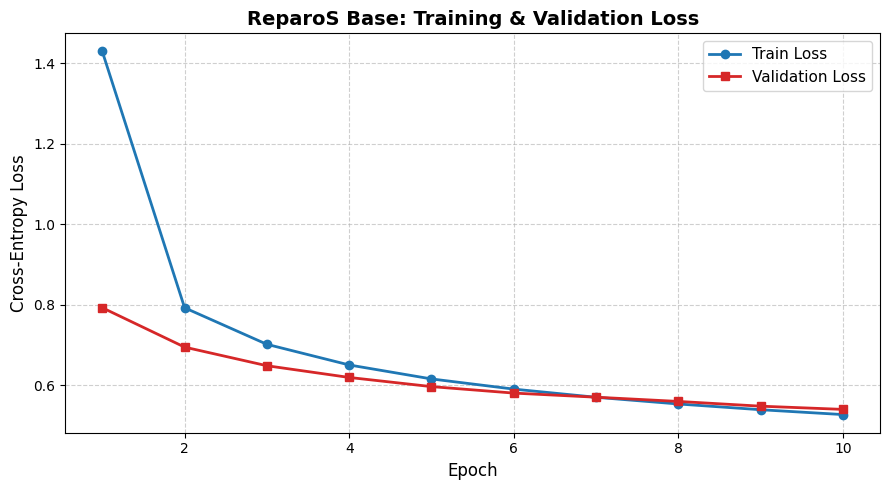

In [6]:
import json
import os
import matplotlib.pyplot as plt

history_file = "artifacts/reparos/base-v1/training-history.jsonl"
epochs, train_losses, val_losses = [], [], []

if os.path.exists(history_file):
    with open(history_file, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line.strip())
            epochs.append(record["epoch"])
            train_losses.append(record["train_loss"])
            val_losses.append(record["validation_loss"])

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, train_losses, marker='o', linewidth=2, color='#1f77b4', label='Train Loss')
    plt.plot(epochs, val_losses, marker='s', linewidth=2, color='#d62728', label='Validation Loss')
    plt.title('ReparoS Base: Training & Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Cross-Entropy Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Chưa tìm thấy file training-history.jsonl. Hãy hoàn thành bước train trước!")

## 7. Thử nghiệm Inference (Dự đoán sửa lỗi câu truy vấn)

Load checkpoint tốt nhất (`best.ckpt`) và thực hiện Beam Search để sinh các gợi ý địa chỉ chuẩn hóa.

In [13]:
import sys
import os

# Thêm thư mục src vào sys.path để Python tìm thấy package reparos
src_path = "/content/QU-solution/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from reparos.inference import ReferencePredictor

model_path = "/content/QU-solution/artifacts/reparos/base-v1/best.ckpt"
tokenizer_path = "/content/QU-solution/artifacts/reparos/tokenizer-v1/tokenizer.model"

# Khởi tạo predictor trên GPU (hoặc CPU nếu không có GPU)
predictor = ReferencePredictor(model_path, tokenizer_path, device="cuda")

test_queries = [
    "san bảy nổi bai",
    "ho gom",
    "benh vien bach mai",
    "pho hue hai ba trung",
    "cau giay ha noi",
    "cho ben thanh quan 1",
    "nga tu so"
]

print("=" * 70)
print(f"{'Truy vấn đầu vào':<30} | {'Dự đoán ReparoS (Top-1)':<35}")
print("=" * 70)

for query in test_queries:
    result = predictor.predict(query, beam_size=10)
    top1 = result["top1_query"]
    print(f"{query:<30} | {top1:<35}")

print("=" * 70)

Truy vấn đầu vào               | Dự đoán ReparoS (Top-1)            
san bảy nổi bai                | san bai bảy nổi                    
ho gom                         | gom hotel                          
benh vien bach mai             | benh vien mai vien                 
pho hue hai ba trung           | pho ba trung hue hai pho           
cau giay ha noi                | cau gia ha noi                     
cho ben thanh quan 1           | cho quan 1 cho thanh quan 1        
nga tu so                      | so tu nga                          


## 8. Sao lưu Checkpoint & Tokenizer vào Google Drive

Google Colab sẽ xóa sạch dữ liệu sau khi session kết thúc (thường sau vài giờ). Hãy chạy ô này để lưu trữ lâu dài mô hình đã train vào Google Drive của bạn.

In [ ]:
!mkdir -p /content/drive/MyDrive/reparos-artifacts
!cp -r artifacts/reparos /content/drive/MyDrive/reparos-artifacts/
print("🎉 Đã sao lưu thành công toàn bộ artifacts vào Google Drive (/content/drive/MyDrive/reparos-artifacts/)!")